### Deep Learning Model Training ()
The goal of this step to to design a neural network that can take a sequence of 150 integers (our cleaned review) and output a prediction for a 10-star rating scale.

I'm  going to design a network using three specific components:

- An Embedding Layer (To understand word meanings)

- A Bidirectional LSTM Layer (To read sentences forward and backward)

- A Dense Output Layer (To make the final 10-class decision)

In [3]:
import os
import numpy as np

# Define path to the processed data
data_path = os.path.join('..', 'dataset', 'processed', 'processed_data.npz')

# Load the arrays
print("Loading preprocessed datasets...")
with np.load(data_path) as data:
    X_train = data['X_train']
    X_test = data['X_test']
    y_train = data['y_train']
    y_test = data['y_test']

print("\n--- Data Loaded Successfully ---")
print(f"X_train shape: {X_train.shape} | y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}  | y_test shape: {y_test.shape}")

# Adjust labels to be 0-indexed for the neural network
# Python arrays start at 0, but our ratings are 1-10. Moving them to 0-9 prevents indexing errors.
y_train_shifted = y_train - 1
y_test_shifted = y_test - 1
print("Shifted ratings range from:", y_train_shifted.min(), "to", y_train_shifted.max())

Loading preprocessed datasets...

--- Data Loaded Successfully ---
X_train shape: (161297, 150) | y_train shape: (161297,)
X_test shape: (53766, 150)  | y_test shape: (53766,)
Shifted ratings range from: 0 to 9


### Building the Bidirectional LSTM

In [5]:
import os
import setuptools
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# 1. Define hyperparameters from Milestone 2 & 3
VOCAB_SIZE = 10000  # Max vocabulary cutoff
MAX_LEN = 150       # Sequence length from EDA
EMBEDDING_DIM = 64  # Size of the word vector space

print("Building Bidirectional LSTM Architecture in TensorFlow...")
model = Sequential([
    # Layer 1: Embedding Layer (Turns word IDs into dense meaning vectors)
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    
    # Layer 2: Bidirectional LSTM (Reads sentence forward and backward)
    Bidirectional(LSTM(64, return_sequences=False)),
    
    # Layer 3: Regularization (Prevents the model from memorizing quirks)
    Dropout(0.5),
    
    # Layer 4: Dense Output Layer (10 units for 10-star rating scale)
    Dense(10, activation='softmax')
])

# 2. Compile the model
# sparse_categorical_crossentropy is used because our labels are single integers (0-9)
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# 3. Define Early Stopping to prevent overfitting and save time
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

print("\nStarting Deep Learning Training Loop...")
# We train for up to 5 epochs, monitoring performance on the test set
history = model.fit(
    X_train, y_train_shifted,
    epochs=5,
    batch_size=256,
    validation_data=(X_test, y_test_shifted),
    callbacks=[early_stop]
)

Building Bidirectional LSTM Architecture in TensorFlow...


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Starting Deep Learning Training Loop...
Epoch 1/5
631/631 ━━━━━━━━━━━━━━━━━━━━ 258s 402ms/step - accuracy: 0.3926 - loss: 1.7374 - val_accuracy: 0.4275 - val_loss: 1.6025
Epoch 2/5
631/631 ━━━━━━━━━━━━━━━━━━━━ 234s 371ms/step - accuracy: 0.4404 - loss: 1.5597 - val_accuracy: 0.4421 - val_loss: 1.5463
Epoch 3/5
631/631 ━━━━━━━━━━━━━━━━━━━━ 255s 405ms/step - accuracy: 0.4554 - loss: 1.4964 - val_accuracy: 0.4502 - val_loss: 1.5373
Epoch 4/5
631/631 ━━━━━━━━━━━━━━━━━━━━ 255s 405ms/step - accuracy: 0.4692 - loss: 1.4471 - val_accuracy: 0.4576 - val_loss: 1.5017
Epoch 5/5
631/631 ━━━━━━━━━━━━━━━━━━━━ 245s 389ms/step - accuracy: 0.4820 - loss: 1.4022 - val_accuracy: 0.4589 - val_loss: 1.5486


In [ ]:
import os

# Create a directory to hold saved models
model_dir = os.path.join('..', 'models')
os.makedirs(model_dir, exist_ok=True)

model_path = os.path.join(model_dir, 'bidi_lstm_rating_model.keras')

# Save the entire architecture, weights, and optimizer configuration
model.save(model_path)
print(f"Model securely saved to disk at: {model_path}")

Model securely saved to disk at: ../models/bidi_lstm_rating_model.keras


In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 150, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,122,016 (8.09 MB)

 Trainable params: 707,338 (2.70 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,414,678 (5.40 MB)

### Generating the Evaluation Metrics

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

print("Generating model predictions on the test dataset...")
# 1. Get raw probability arrays from the network (e.g., [0.05, 0.1, ..., 0.75])
raw_predictions = model.predict(X_test)

# 2. Use argmax to pick the highest probability slot (0-9) as the definitive prediction
y_pred_shifted = np.argmax(raw_predictions, axis=1)

# 3. Shift the predictions and targets back to human-readable scores (1-10)
y_pred = y_pred_shifted + 1
y_true = y_test  # This is already 1-10

# 4. Generate the complete classification report
print("\n================== FINAL CLASSIFICATION REPORT ==================\n")
# Target names map our indices cleanly back to "Rating 1" through "Rating 10"
target_names = [f"Rating {i}" for i in range(1, 11)]
print(classification_report(y_true, y_pred, target_names=target_names))

Generating model predictions on the test dataset...
1681/1681 ━━━━━━━━━━━━━━━━━━━━ 93s 55ms/step

================== FINAL CLASSIFICATION REPORT ==================

              precision    recall  f1-score   support

    Rating 1       0.52      0.80      0.63      7299
    Rating 2       0.00      0.00      0.00      2334
    Rating 3       0.17      0.06      0.09      2205
    Rating 4       0.00      0.00      0.00      1659
    Rating 5       0.17      0.23      0.19      2710
    Rating 6       0.00      0.00      0.00      2119
    Rating 7       0.19      0.02      0.04      3091
    Rating 8       0.24      0.34      0.28      6156
    Rating 9       0.36      0.19      0.25      9177
   Rating 10       0.57      0.81      0.67     17016

    accuracy                           0.45     53766
   macro avg       0.22      0.25      0.22     53766
weighted avg       0.37      0.45      0.39     53766



/Users/macbook/Documents/Code/drug-review-rating-prediction/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/macbook/Documents/Code/drug-review-rating-prediction/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/macbook/Documents/Code/drug-review-rating-prediction/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zer

### Fixing Sever Class Imbalance

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# 1. Calculate the optimal mathematical weights for all 10 classes
print("Calculating class weights to balance the loss function...")
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_shifted),
    y=y_train_shifted
)

# Converting the array into a dictionary format mapping: {class_index: weight_value}
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

print("\nComputed Balances:")
for rating_idx, weight in class_weight_dict.items():
    print(f"  Shifted Class {rating_idx} (Human Rating {rating_idx + 1}): Weight = {weight:.4f}")

# 2. Re-initialize a fresh, un-trained model architecture
VOCAB_SIZE = 10000
MAX_LEN = 150
EMBEDDING_DIM = 64

balanced_model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

balanced_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 3. Define our Early Stopping guardrail
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

print("\nStarting Weighted Deep Learning Training Loop...")
# We inject the class_weight dictionary directly into the fit execution
history_weighted = balanced_model.fit(
    X_train, y_train_shifted,
    epochs=5,
    batch_size=256,
    validation_data=(X_test, y_test_shifted),
    class_weight=class_weight_dict,
    callbacks=[early_stop]
)

Calculating class weights to balance the loss function...

Computed Balances:
  Shifted Class 0 (Human Rating 1): Weight = 0.7461
  Shifted Class 1 (Human Rating 2): Weight = 2.3272
  Shifted Class 2 (Human Rating 3): Weight = 2.4765
  Shifted Class 3 (Human Rating 4): Weight = 3.2182
  Shifted Class 4 (Human Rating 5): Weight = 2.0129
  Shifted Class 5 (Human Rating 6): Weight = 2.5429
  Shifted Class 6 (Human Rating 7): Weight = 1.7058
  Shifted Class 7 (Human Rating 8): Weight = 0.8539
  Shifted Class 8 (Human Rating 9): Weight = 0.5859
  Shifted Class 9 (Human Rating 10): Weight = 0.3163


/Users/macbook/Documents/Code/drug-review-rating-prediction/venv/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(



Starting Weighted Deep Learning Training Loop...
Epoch 1/5
631/631 ━━━━━━━━━━━━━━━━━━━━ 293s 456ms/step - accuracy: 0.2853 - loss: 2.0897 - val_accuracy: 0.3415 - val_loss: 1.8506
Epoch 2/5
631/631 ━━━━━━━━━━━━━━━━━━━━ 312s 494ms/step - accuracy: 0.3597 - loss: 1.9153 - val_accuracy: 0.3172 - val_loss: 1.9576
Epoch 3/5
631/631 ━━━━━━━━━━━━━━━━━━━━ 281s 445ms/step - accuracy: 0.3729 - loss: 1.8402 - val_accuracy: 0.3712 - val_loss: 1.7205
Epoch 4/5
631/631 ━━━━━━━━━━━━━━━━━━━━ 304s 482ms/step - accuracy: 0.3875 - loss: 1.7749 - val_accuracy: 0.3295 - val_loss: 1.9337
Epoch 5/5
631/631 ━━━━━━━━━━━━━━━━━━━━ 286s 454ms/step - accuracy: 0.3970 - loss: 1.7234 - val_accuracy: 0.3834 - val_loss: 1.6808


In [ ]:
import numpy as np
from sklearn.metrics import classification_report

print("Evaluating balanced model predictions on the test dataset...")
# 1. Predict probabilities using the new balanced network
raw_predictions_weighted = balanced_model.predict(X_test)

# 2. Extract the indices of the highest probabilities
y_pred_shifted_weighted = np.argmax(raw_predictions_weighted, axis=1)

# 3. Shift back to human-readable scales (1-10)
y_pred_weighted = y_pred_shifted_weighted + 1
y_true = y_test

# 4. Generate the balanced classification report
print("\n================== BALANCED MODEL CLASSIFICATION REPORT ==================\n")
target_names = [f"Rating {i}" for i in range(1, 11)]
print(classification_report(y_true, y_pred_weighted, target_names=target_names))

Evaluating balanced model predictions on the test dataset...
1681/1681 ━━━━━━━━━━━━━━━━━━━━ 81s 48ms/step

================== BALANCED MODEL CLASSIFICATION REPORT ==================

              precision    recall  f1-score   support

    Rating 1       0.58      0.55      0.56      7299
    Rating 2       0.20      0.20      0.20      2334
    Rating 3       0.17      0.18      0.18      2205
    Rating 4       0.16      0.30      0.21      1659
    Rating 5       0.17      0.31      0.22      2710
    Rating 6       0.13      0.27      0.18      2119
    Rating 7       0.15      0.20      0.17      3091
    Rating 8       0.23      0.14      0.17      6156
    Rating 9       0.34      0.19      0.24      9177
   Rating 10       0.64      0.62      0.63     17016

    accuracy                           0.38     53766
   macro avg       0.28      0.30      0.28     53766
weighted avg       0.41      0.38      0.39     53766



### Saving The Optimized Model

In [ ]:
import os

model_dir = os.path.join('..', 'models')
os.makedirs(model_dir, exist_ok=True)

balanced_model_path = os.path.join(model_dir, 'bidi_lstm_balanced_model.keras')

# Save the newly trained balanced network
balanced_model.save(balanced_model_path)
print(f"Optimized balanced model securely saved at: {balanced_model_path}")

Optimized balanced model securely saved at: ../models/bidi_lstm_balanced_model.keras


### Generating the Classification Report:

Generating Optimized Balanced Model predictions on the test subset...
1681/1681 ━━━━━━━━━━━━━━━━━━━━ 52s 31ms/step

================== BALANCED MODEL PERFORMANCE METRICS ==================

              precision    recall  f1-score   support

    Rating 1       0.49      0.85      0.62      7299
    Rating 2       0.20      0.00      0.00      2334
    Rating 3       0.16      0.02      0.04      2205
    Rating 4       0.00      0.00      0.00      1659
    Rating 5       0.18      0.20      0.19      2710
    Rating 6       0.00      0.00      0.00      2119
    Rating 7       0.19      0.05      0.08      3091
    Rating 8       0.25      0.24      0.24      6156
    Rating 9       0.34      0.21      0.26      9177
   Rating 10       0.57      0.84      0.67     17016

    accuracy                           0.46     53766
   macro avg       0.24      0.24      0.21     53766
weighted avg       0.37      0.46      0.39     53766

Plotting and saving Confusion Matrix...


/Users/macbook/Documents/Code/drug-review-rating-prediction/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/macbook/Documents/Code/drug-review-rating-prediction/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/macbook/Documents/Code/drug-review-rating-prediction/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zer

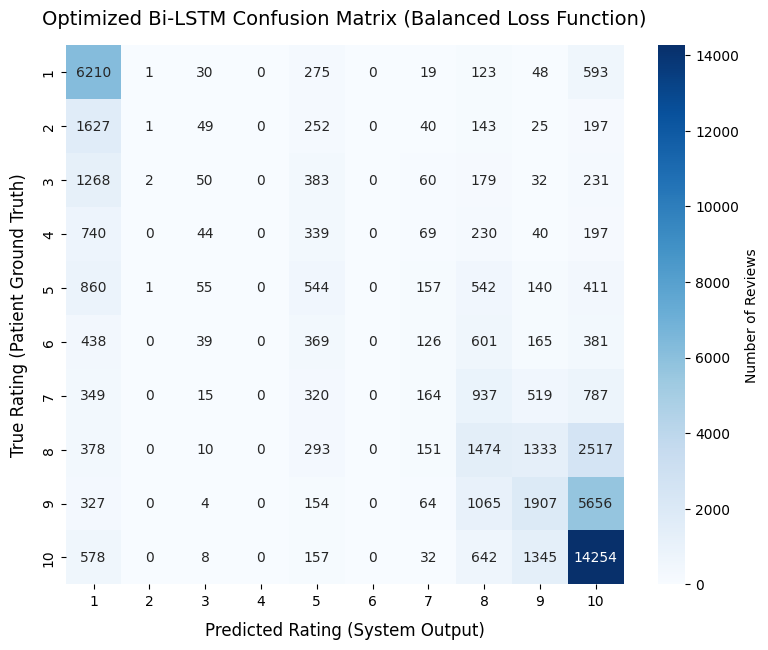


Success! Confusion Matrix graphic securely saved to disk at: ../outputs/confusion_matrix.png


In [7]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

print("Generating Optimized Balanced Model predictions on the test subset...")

# 1. Generate predictions from your loaded balanced model
# Note: if your gen AI notebook named the model variable something else, swap out `model` here
raw_preds_full = model.predict(X_test, verbose=1)

# 2. Extract highest probability indices (0-9 scale) and shift back to human ratings (1-10)
y_pred_shifted = np.argmax(raw_preds_full, axis=1)
y_pred = y_pred_shifted + 1
y_true = y_test  # Original ground truth labels (1-10 scale)

# 3. Print the Final Balanced Classification Report to your console
print("\n================== BALANCED MODEL PERFORMANCE METRICS ==================\n")
target_names = [f"Rating {i}" for i in range(1, 11)]
print(classification_report(y_true, y_pred, target_names=target_names))

# 4. Generate and Plot the Confusion Matrix
print("Plotting and saving Confusion Matrix...")
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=range(1, 11), 
    yticklabels=range(1, 11),
    cbar_kws={'label': 'Number of Reviews'}
)

plt.title('Optimized Bi-LSTM Confusion Matrix (Balanced Loss Function)', fontsize=14, pad=15)
plt.xlabel('Predicted Rating (System Output)', fontsize=12, labelpad=10)
plt.ylabel('True Rating (Patient Ground Truth)', fontsize=12, labelpad=10)

# 5. Securely save the matrix into your outputs folder for the PDF report
output_dir = os.path.join('..', 'outputs')
os.makedirs(output_dir, exist_ok=True)
matrix_path = os.path.join(output_dir, 'confusion_matrix.png')

plt.savefig(matrix_path, bbox_inches='tight', dpi=300)
plt.show()

print(f"\nSuccess! Confusion Matrix graphic securely saved to disk at: {matrix_path}")